## Parte 0

In [2]:
!pip3 install torch torchvision --index-url https://download.pytorch.org/whl/cu126

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cu126
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/2.6 GB ? eta -:--:--
   ---------------------------------------- 0.0/2.6 GB 8.4 MB/s eta 0:05:11
   ---------------------------------------- 0.0/2.6 GB 8.0 MB/s eta 0:05:26
   ---------------------------------------- 0.0/2.6 GB 9.1 MB/s eta 0:04:46
   ---------------------------------------- 0.0/2.6 GB 10.1 MB/s eta 0:04:17
   ---------------------------------------- 0.0/2.6 GB 11.1 MB/s eta 0:03:54
   ---------------------------------------- 0.0/2.6 GB 11.9 MB/s eta 0:03:38
   ---------------------------------------- 0.0/2.6 GB 12.0 MB/s eta 0:03:36
   ---------------------------------------- 0.0/2.6 GB 11.7 MB/s eta 0:03:42
   ---------------------------------------- 0.0/2.6 GB 1

ERROR: Could not install packages due to an OSError: [WinError 206] O nome do arquivo ou a extensão é muito grande: 'C:\\Users\\walle\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python312\\site-packages\\torch-2.14.0+cu126.dist-info\\licenses\\third_party\\flash-attention\\third_party\\aiter\\3rdparty\\composable_kernel'



In [1]:
import numpy as np 
import random
import matplotlib.pyplot as plt
import cv2
import time

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

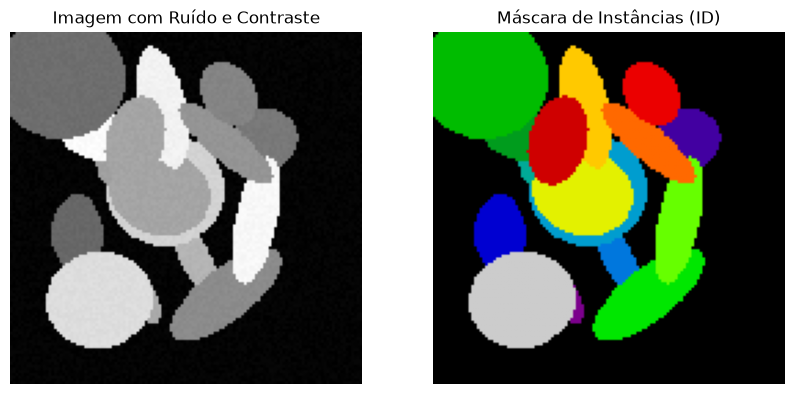

In [2]:
def generateEllipses(img_size):
    # Vamos adicinar um contraste para o fundo da imagem
    bg_intensity = np.random.randint(20,80)
    img = np.full((img_size, img_size), bg_intensity, dtype=np.uint8)

    # Evitar overflow
    mask = np.zeros((img_size, img_size), dtype=np.int32)

    num_ellipses = np.random.randint(15,21)

    # Para cada elipse, define o formato, a posição e a intensidade
    for i in range(1, num_ellipses+1):
        center = (int(np.random.randint(15, img_size-15)), int(np.random.randint(15, img_size-15)))
        axes = (int(np.random.randint(5,25)), int(np.random.randint(5,25)))
        angle = int(np.random.randint(0,180))
        intensity = int(np.random.randint(100,255))

        cv2.ellipse(img, center, axes, angle, 0, 360, intensity, -1)
        cv2.ellipse(mask, center, axes, angle, 0, 360, i, -1)

    std_dev = np.random.uniform(5.0, 30.0)
    noise = np.random.uniform(0, std_dev, (img_size, img_size))

    noisy_img = np.clip(img + noise, 0, 255)

    return noisy_img, mask

img, mask = generateEllipses(128)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img, cmap='gray')
axes[0].set_title("Imagem com Ruído e Contraste")
axes[0].axis('off')

axes[1].imshow(mask, cmap='nipy_spectral')
axes[1].set_title("Máscara de Instâncias (ID)")
axes[1].axis('off')
plt.show()

In [3]:
class EllipsesDataset(Dataset):
  def __init__(self, num_samples) -> None:
     self.num_samples = num_samples
    
  def __len__(self):
    return self.num_samples
  
  def __getitem__(self, index):
    img, mask = generateEllipses(128)
    tensor_img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
    tensor_mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)
    return tensor_img, tensor_mask

ellip_data_train = EllipsesDataset(800)
ellip_loader_train = DataLoader(ellip_data_train, batch_size=16)

ellip_data_val = EllipsesDataset(200)
ellip_loader_val = DataLoader(ellip_data_val, batch_size=16)

In [178]:
# Para treinar com as elipses criadas acima usaremos a U-Net
class DoubleConv(nn.Module):
   def __init__(self, in_channels, out_channels) -> None:
      super(DoubleConv, self).__init__()
      self.conv = nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True)
      )

   def forward(self,x):
     return self.conv(x)

class UNet(nn.Module):
   def __init__(self, in_channels, out_channels) -> None:
      super(UNet, self).__init__()
      # Encoder
      self.conv1 = DoubleConv(in_channels, 64)
      self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
      self.conv2 = DoubleConv(64,128)
      self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

      # Bottleneck
      self.bottleneck = DoubleConv(128,256)

      # Decoder
      self.up1 = nn.ConvTranspose2d(256,128,kernel_size=2, stride=2)
      self.dec1 = DoubleConv(256,128)
      self.up2 = nn.ConvTranspose2d(128,64,kernel_size=2, stride=2)
      self.dec2 = DoubleConv(128,64)

      # Output
      self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)

   def forward(self, x):
      # Passa pelo primeiro bloco e salva
      skip1 = self.conv1(x)
      x = self.pool1(skip1)
      skip2 = self.conv2(x)
      x = self.pool2(skip2)

      x = self.bottleneck(x)
      x = self.up1(x)

      x = F.interpolate(
        x,
        size=skip2.shape[2:],
        mode="bilinear",
        align_corners=False
      )
      x = torch.cat((skip2, x), dim=1)
      x = self.dec1(x)
      x = self.up2(x)
      
      x = F.interpolate(
        x,
        size=skip1.shape[2:],
        mode="bilinear",
        align_corners=False
      )
      x = torch.cat((skip1, x), dim=1)
      x = self.dec2(x)

      return self.final_conv(x)

In [11]:
# Treino do modelo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet(in_channels=1, out_channels=1).to(device)
loss = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

time_begin = time.time()

for epoch in range(50):
  loss_train = 0.0
  model.train()
  for img, mask in ellip_loader_train:
    img = img.to(device)
    mask = mask.to(device)
    mask = (mask > 0).float()

    optimizer.zero_grad()
    pred = model(img)
    loss_value = loss(pred, mask)
    loss_train += loss_value.item()
    loss_value.backward()
    optimizer.step()
  mean_loss_train = loss_train / len(ellip_loader_train)

  loss_val = 0.0
  model.eval()
  total_iou = 0.0
  total_dice = 0.0
  with torch.no_grad():
    for img, mask in ellip_loader_val:
      img = img.to(device)
      mask = mask.to(device)
      mask = (mask > 0).float()

      pred = model(img)
      loss_value = loss(pred, mask)
      loss_val += loss_value.item()
      pred_prob = torch.sigmoid(pred)
      pred = (pred_prob > 0.5).float()

      intersection = torch.sum((pred*mask))
      union = torch.sum((pred+mask)) - intersection
      iou = intersection / union
      dice = 2 * intersection / (torch.sum(pred) + torch.sum(mask) + 1e-8)

      total_iou += iou.item()
      total_dice += dice.item()
  mean_loss_val = loss_val / len(ellip_loader_val)
  mean_iou = total_iou / len(ellip_loader_val)
  mean_dice = total_dice / len(ellip_loader_val)

  if (epoch + 1) % 5 == 0 or epoch == 0:
      print(f"Epoch [{epoch+1}/50] | Val IoU: {mean_iou:.4f} | Val Dice: {mean_dice:.4f}")
      print(f"Train loss: {mean_loss_train} | Val loss: {mean_loss_val}")

  if mean_iou > 0.99:
    print(f"Early stropping")
    break

time_end = time.time()
print(f"Train time: {(time_end - time_begin)/60} minutes")


Epoch [1/50] | Val IoU: 0.9738 | Val Dice: 0.9867
Train loss: 0.12760794058442115 | Val loss: 0.08475949959113048
Early stropping
Train time: 0.3076512853304545 minutes


# Parte 1

In [113]:
from pathlib import Path

class BBBC038Dataset(Dataset):

    def __init__(self, root):
        self.root = Path(root)

        # Encontra todas as imagens 
        self.images = sorted(self.root.glob("*/images/*.png"))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image_path = self.images[idx]

        # Pasta correspondente à imagem
        sample_dir = image_path.parent.parent

        # Carrega a imagem em um tensor
        image = cv2.imread(image_path)
        image = torch.tensor(image, dtype=torch.float32)
        image = image.permute(2, 0, 1).unsqueeze(0)

        # Carrega as mascaras
        mask_paths = sorted((sample_dir / "masks").glob("*.png"))

        masks = []

        for mask_path in mask_paths:
            mask = cv2.imread(mask_path)
            mask = torch.tensor(mask, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0)
            masks.append(mask)

        masks = torch.stack(masks).max(dim=0).values
        masks = (masks.any(dim=1)).int().unsqueeze(0)

        return image, masks

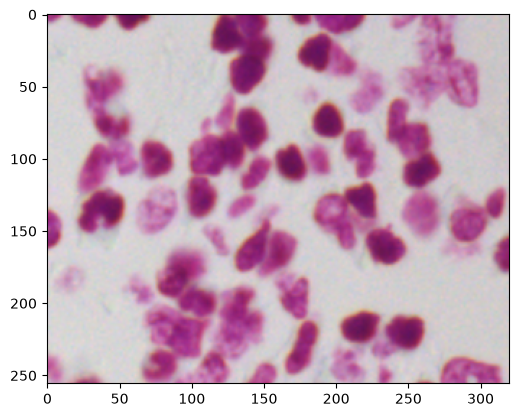

In [167]:
plt.imshow(images[2][0].byte().permute(1, 2, 0))

In [ ]:
dataset = BBBC038Dataset("data/stage1_train")

images = []
masks = []
for i in range(len(dataset)):
    image, mask = dataset[i]
    images.append(image)
    masks.append(mask)


print(len(images))
print(len(masks))

RuntimeError: stack expects each tensor to be equal size, but got [1, 3, 256, 256] at entry 0 and [1, 3, 256, 320] at entry 2

In [172]:
for img, mask in ellip_loader_val:
    print(img.shape)
    break

torch.Size([16, 1, 128, 128])


In [173]:
for img, mask in zip(images, masks):
    print(img.shape)
    break

torch.Size([1, 3, 256, 256])


In [ ]:
# Treino do modelo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet(in_channels=3, out_channels=1).to(device)
loss = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

time_begin = time.time()

for epoch in range(50):
  loss_train = 0.0
  model.train()
  for img, mask in zip(images, masks):
    img = img.to(device)
    mask = mask.to(device)
    mask = (mask > 0).float()

    optimizer.zero_grad()
    try:
      pred = model(img)
    except Exception as e:
      print(img.shape)
      raise Exception(e)
    loss_value = loss(pred, mask)
    loss_train += loss_value.item()
    loss_value.backward()
    optimizer.step()
  mean_loss_train = loss_train / len(dataset)

  loss_val = 0.0
  model.eval()
  total_iou = 0.0
  total_dice = 0.0
  with torch.no_grad():
    for img, mask in zip(images, masks):
      img = img.to(device)
      mask = mask.to(device)
      mask = (mask > 0).float()

      pred = model(img)
      loss_value = loss(pred, mask)
      loss_val += loss_value.item()
      pred_prob = torch.sigmoid(pred)
      pred = (pred_prob > 0.5).float()

      intersection = torch.sum((pred*mask))
      union = torch.sum((pred+mask)) - intersection
      iou = intersection / union
      dice = 2 * intersection / (torch.sum(pred) + torch.sum(mask) + 1e-8)

      total_iou += iou.item()
      total_dice += dice.item()
  mean_loss_val = loss_val / len(dataset)
  mean_iou = total_iou / len(dataset)
  mean_dice = total_dice / len(dataset)

  if (epoch + 1) % 5 == 0 or epoch == 0:
      print(f"Epoch [{epoch+1}/50] | Val IoU: {mean_iou:.4f} | Val Dice: {mean_dice:.4f}")
      print(f"Train loss: {mean_loss_train} | Val loss: {mean_loss_val}")

  if mean_iou > 0.99:
    print(f"Early stropping")
    break

time_end = time.time()
print(f"Train time: {(time_end - time_begin)/60} minutes")


Epoch [1/50] | Val IoU: 0.5930 | Val Dice: 0.6920
Train loss: 0.13736210292233014 | Val loss: 2.4280794427854375
Epoch [5/50] | Val IoU: 0.5472 | Val Dice: 0.6417
Train loss: 0.07176873787174196 | Val loss: 1.62746263199187
Epoch [10/50] | Val IoU: 0.5281 | Val Dice: 0.6199
Train loss: 0.06577563446897791 | Val loss: 1.660158331127257


torch.Size([256, 256, 3])


TypeError: Invalid shape (3, 256, 256) for image data

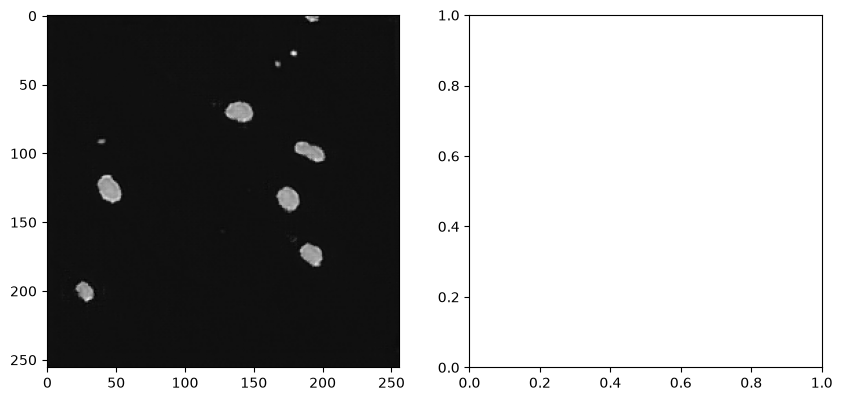

In [ ]:
with torch.no_grad():
    for img, mask, i in zip(images, masks, range(len(images))):
      if i < 20: continue
      elif i > 20: break
      img = img.to(device)
      mask = mask.to(device)
      mask = (mask > 0).float()
      
      pred = model(img)
      pred = pred[0].cpu().numpy()
      print(img[0].permute(1, 2, 0).shape)
      fig, axes = plt.subplots(1, 2, figsize=(10, 10))
      axes[0].imshow(pred[0], cmap='gray')
      axes[1].imshow(img[0].byte().cpu().numpy())